# A1 - PyTorch refresher: the training loop you'll reuse everywhere

**Goal.** Re-ground the basics you saw in *Intermediate Deep Learning with PyTorch*:
a model is an `nn.Module`, data comes from a `DataLoader`, and *training is a loop*
(forward -> loss -> `backward()` -> `optimizer.step()`).

Everything later in this repo - the ResNet (A2), the RNN (A3), the policy/value
net (A4) and even the supervised step *inside* AlphaZero self-play - is this same
loop. We keep it in one place: `azl.foundations.train_loop.fit`.

> **Maps to raccoon:** the SGD step in `raccoon/train/coach.py` `training_phase`
> is exactly this loop, just with a two-part loss (see A4).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from azl.foundations.data import mnist_loaders
from azl.foundations.models import MLP
from azl.foundations.train_loop import fit, count_parameters

torch.manual_seed(0)

# A subset keeps this fast; raise num_train (or drop it) for the full dataset.
train_loader, test_loader = mnist_loaders(batch_size=128, view="flat", num_train=8000)
print("one batch:", next(iter(train_loader))[0].shape)  # (B, 784) flattened digits

one batch: torch.Size([128, 784])


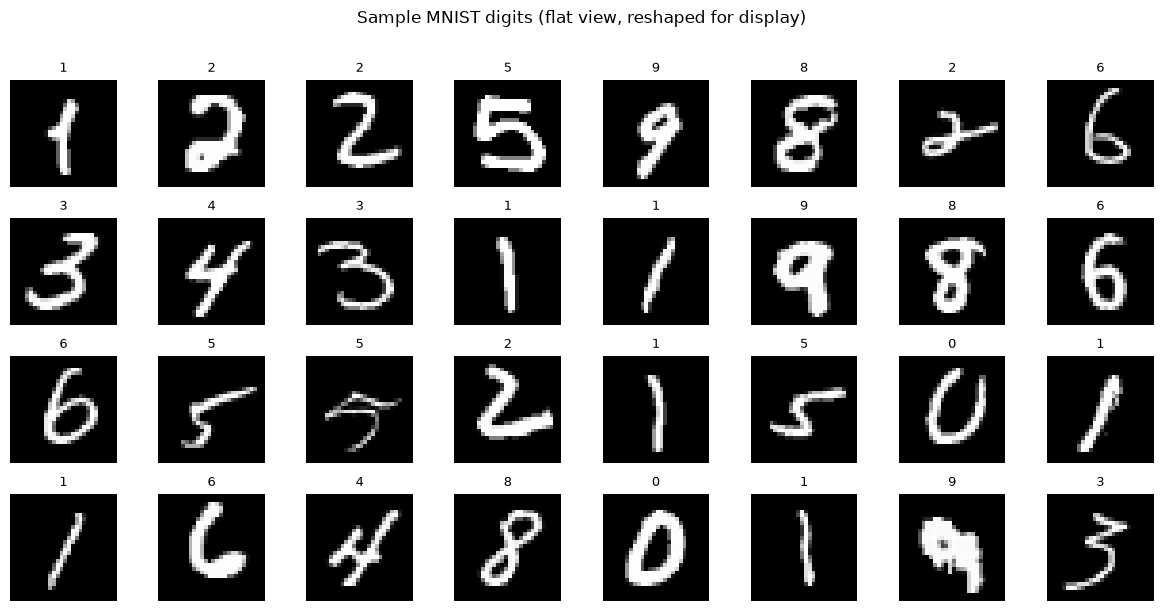

In [2]:
# Peek at a few examples so we know what we're training on.
images, labels = next(iter(train_loader))  # (128, 784) and (128,)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(label.item(), fontsize=9)
    ax.axis("off")
plt.suptitle("Sample MNIST digits (flat view, reshaped for display)", y=1.01)
plt.tight_layout()
plt.show()


In [3]:
model = MLP(in_features=784, hidden=256, num_classes=10)
print(f"{count_parameters(model):,} parameters")

history = fit(model, train_loader, test_loader, epochs=10, lr=1e-3)

269,322 parameters
epoch  1/10  train_loss 0.6449  val_loss 0.3550  val_acc 0.8924
epoch  2/10  train_loss 0.2457  val_loss 0.2530  val_acc 0.9240
epoch  3/10  train_loss 0.1663  val_loss 0.2247  val_acc 0.9286
epoch  4/10  train_loss 0.1222  val_loss 0.2177  val_acc 0.9357
epoch  5/10  train_loss 0.0952  val_loss 0.1951  val_acc 0.9412
epoch  6/10  train_loss 0.0686  val_loss 0.1925  val_acc 0.9421
epoch  7/10  train_loss 0.0472  val_loss 0.1934  val_acc 0.9429
epoch  8/10  train_loss 0.0312  val_loss 0.1846  val_acc 0.9479
epoch  9/10  train_loss 0.0221  val_loss 0.1934  val_acc 0.9467
epoch 10/10  train_loss 0.0156  val_loss 0.2018  val_acc 0.9469


In [4]:
history
pd.DataFrame(history)

,train_loss,val_loss,val_acc
0,0.644903,0.355033,0.8924
1,0.245690,0.252990,0.9240
2,0.166320,0.224731,0.9286
3,0.122189,0.217681,0.9357
4,0.095235,0.195140,0.9412
5,0.068580,0.192512,0.9421
6,0.047227,0.193369,0.9429
7,0.031200,0.184624,0.9479
8,0.022083,0.193430,0.9467
9,0.015616,0.201787,0.9469


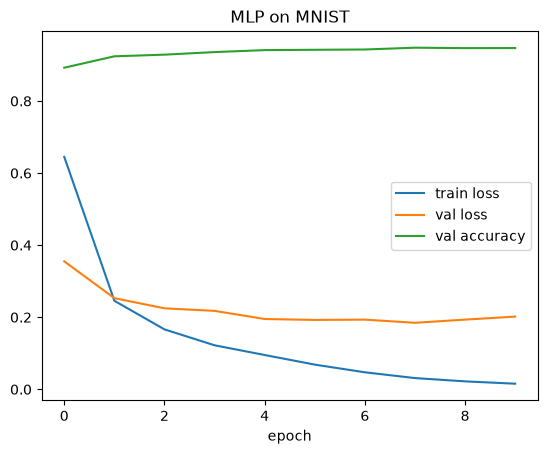

final test accuracy: 0.9469


In [5]:
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.plot(history["val_acc"], label="val accuracy")
plt.xlabel("epoch")
plt.legend()
plt.title("MLP on MNIST")
plt.show()
print("final test accuracy:", history["val_acc"][-1])

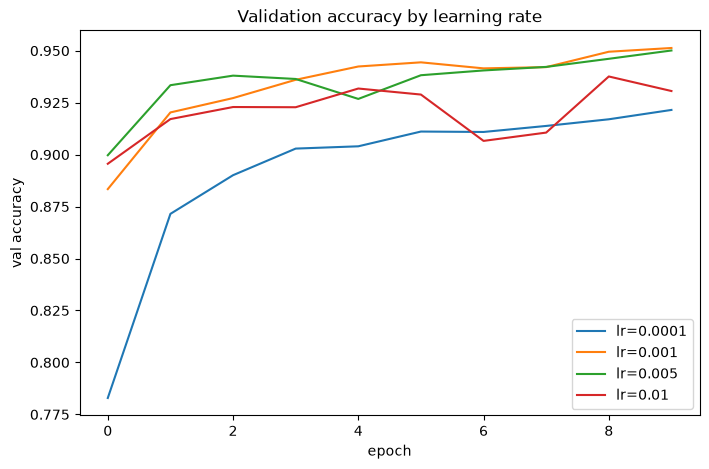

In [6]:
learning_rates = [1e-4, 1e-3, 5e-3, 1e-2]
lr_histories = {}

for lr in learning_rates:
    torch.manual_seed(0)
    m = MLP(in_features=784, hidden=256, num_classes=10)
    lr_histories[lr] = fit(m, train_loader, test_loader, epochs=10, lr=lr, verbose=False)

plt.figure(figsize=(8, 5))
for lr, h in lr_histories.items():
    plt.plot(h["val_acc"], label=f"lr={lr}")
plt.xlabel("epoch")
plt.ylabel("val accuracy")
plt.title("Validation accuracy by learning rate")
plt.legend()
plt.show()


computed and cached


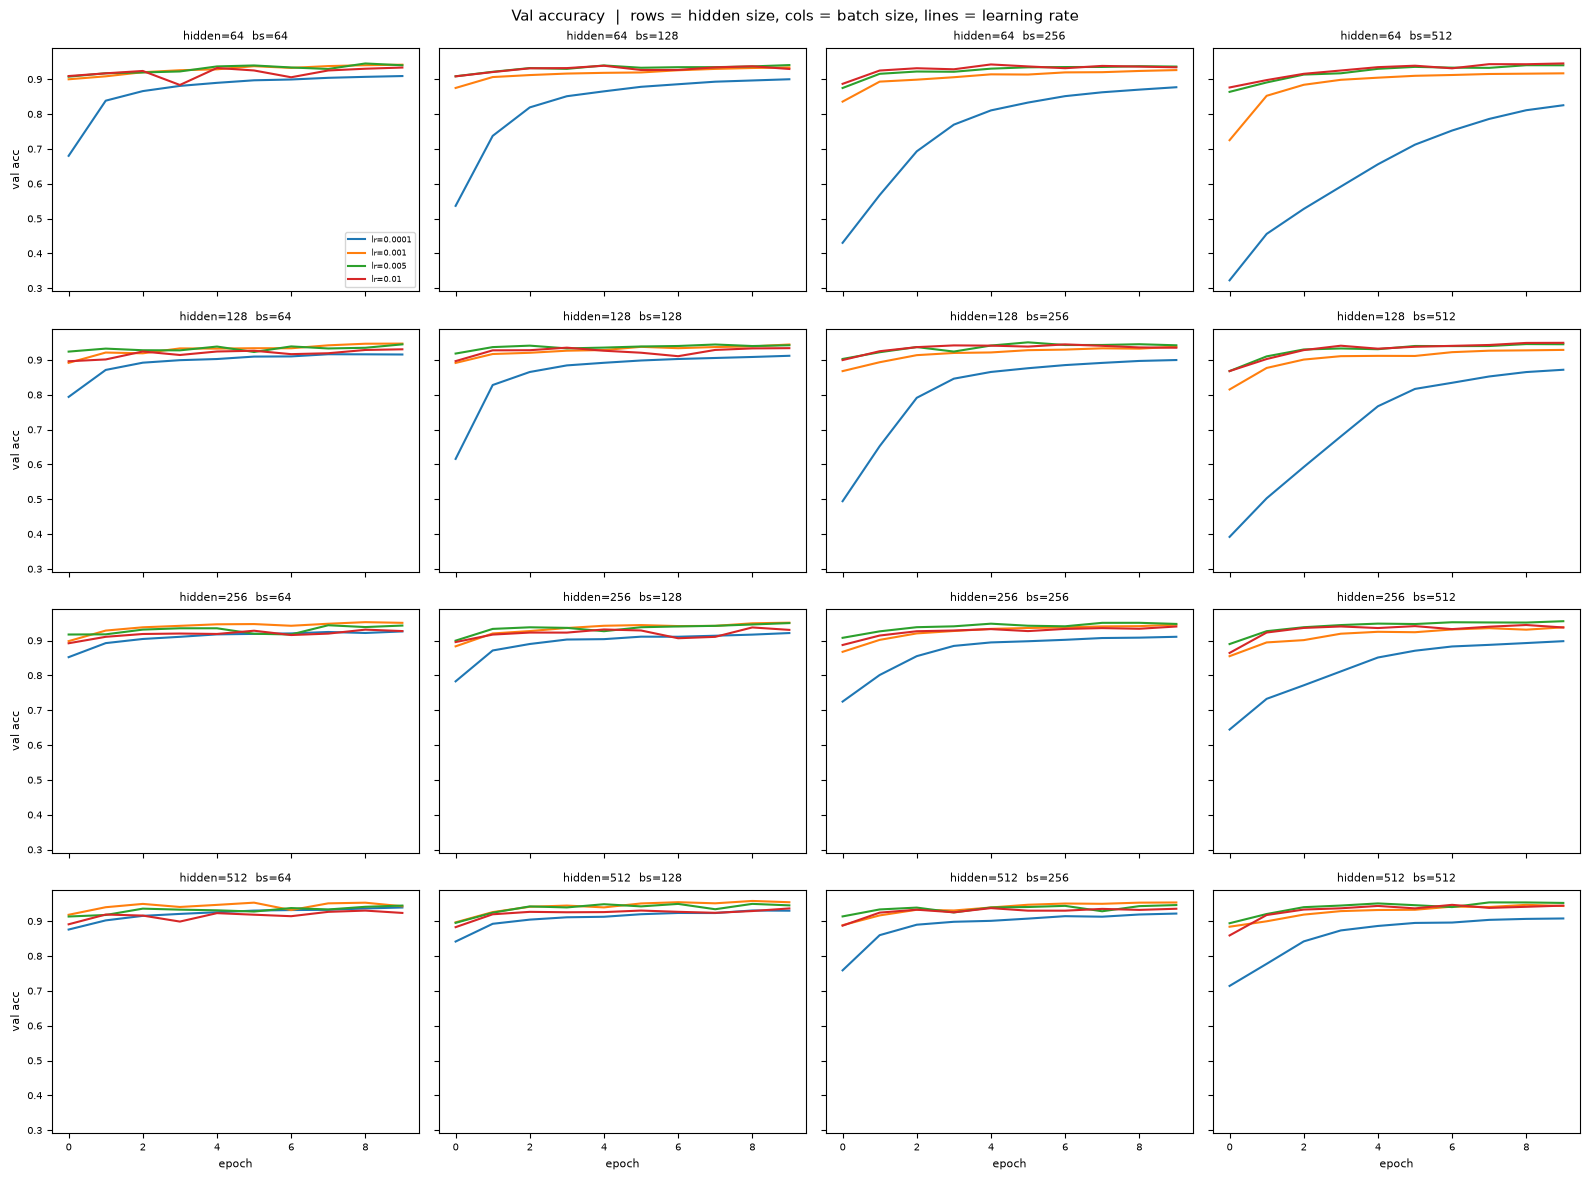

In [ ]:
import pickle, pathlib

batch_sizes    = [64, 128, 256, 512]
hidden_sizes   = [64, 128, 256, 512]
learning_rates = [1e-4, 1e-3, 5e-3, 1e-2]
epochs = 10

_cache = pathlib.Path("cache_lr_bs_hidden.pkl") # Becasue this takes +1h
if _cache.exists():
    grid_results = pickle.loads(_cache.read_bytes())
    print("loaded from cache")
else:
    grid_results = {}
    for hidden in hidden_sizes:
        for bs in batch_sizes:
            tr, te = mnist_loaders(batch_size=bs, view="flat", num_train=8000)
            for lr in learning_rates:
                torch.manual_seed(0)
                m = MLP(in_features=784, hidden=hidden, num_classes=10)
                grid_results[(hidden, bs, lr)] = fit(m, tr, te, epochs=epochs, lr=lr, verbose=False)
    _cache.write_bytes(pickle.dumps(grid_results))
    print("computed and cached")

fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle("Val accuracy  |  rows = hidden size, cols = batch size, lines = learning rate", fontsize=11)

for row, hidden in enumerate(hidden_sizes):
    for col, bs in enumerate(batch_sizes):
        ax = axes[row, col]
        for lr in learning_rates:
            h = grid_results[(hidden, bs, lr)]
            ax.plot(h["val_acc"], label=f"lr={lr}")
        ax.set_title(f"hidden={hidden}  bs={bs}", fontsize=8)
        ax.tick_params(labelsize=7)

for ax in axes[-1]:
    ax.set_xlabel("epoch", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("val acc", fontsize=8)

axes[0, 0].legend(fontsize=6, loc="lower right")
plt.tight_layout()
plt.show()


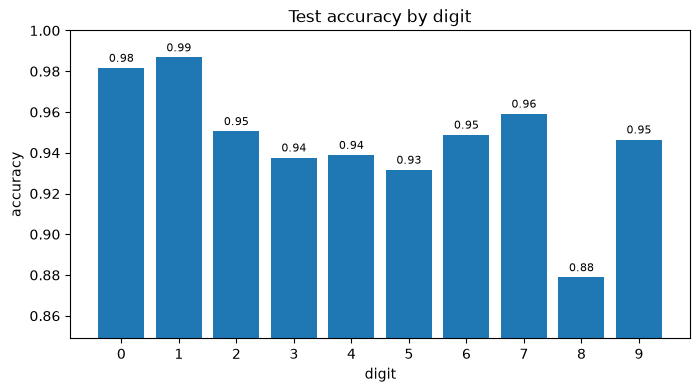

In [7]:
# Accuracy broken down by digit class
model.eval()
device = next(model.parameters()).device
correct_per = torch.zeros(10)
total_per   = torch.zeros(10)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        for c in range(10):
            mask = labels == c
            correct_per[c] += (preds[mask] == labels[mask]).sum().item()
            total_per[c]   += mask.sum().item()

acc_per = (correct_per / total_per).numpy()

plt.figure(figsize=(8, 4))
bars = plt.bar(range(10), acc_per)
plt.xticks(range(10))
plt.xlabel("digit")
plt.ylabel("accuracy")
plt.title("Test accuracy by digit")
plt.ylim(acc_per.min() - 0.03, 1.0)
for i, a in enumerate(acc_per):
    plt.text(i, a + 0.003, f"{a:.2f}", ha="center", fontsize=8)
plt.show()


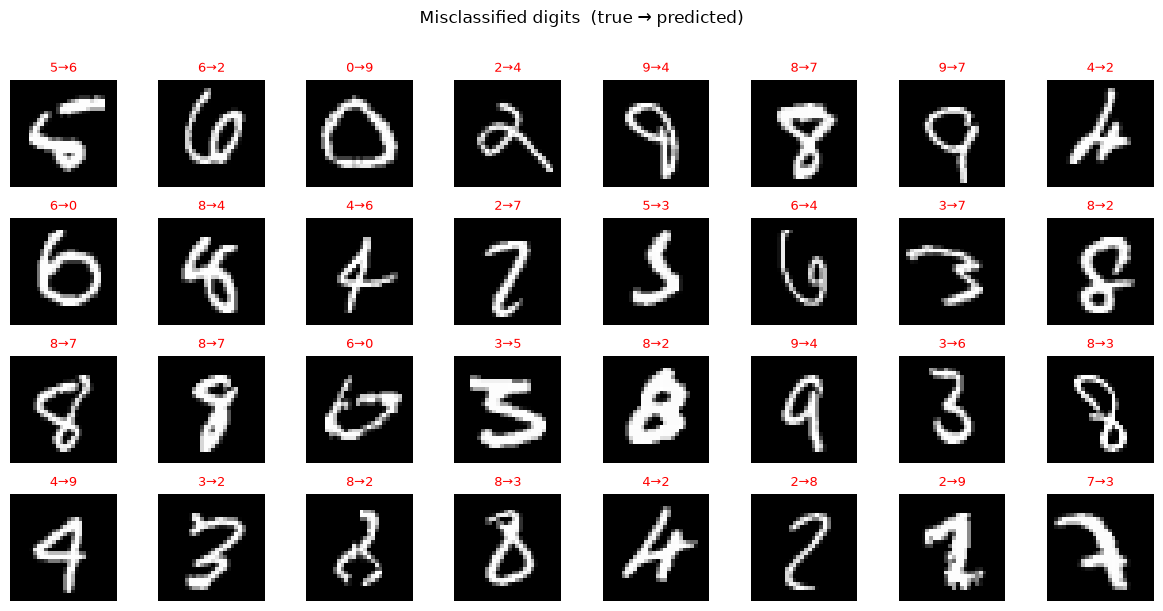

In [8]:
# Sample of misclassified digits -- would a human also struggle?
model.eval()
misclassified = []  # (image, true_label, pred_label)

with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        wrong = preds != labels
        for img, true, pred in zip(imgs[wrong], labels[wrong], preds[wrong]):
            misclassified.append((img, true.item(), pred.item()))
        if len(misclassified) >= 32:
            break

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for ax, (img, true, pred) in zip(axes.flat, misclassified):
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(f"{true}→{pred}", fontsize=9, color="red")
    ax.axis("off")
plt.suptitle("Misclassified digits  (true → predicted)", y=1.01)
plt.tight_layout()
plt.show()


### Things to tweak
- `hidden`, `epochs`, `lr`, `num_train` - watch the loss curve and accuracy move.
- Switch `view="image"` and feed the same MLP (it flattens internally).

### Takeaway
A plain MLP already gets MNIST mostly right, but it throws away the 2D structure of
the image. The next notebook adds an inductive bias that *uses* that structure -
convolutions and residual blocks - which is the trunk raccoon's network is built
from.